Take a look at the [repository](https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix) for more information

# Install

In [1]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.23 MiB | 16.09 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.


In [2]:
import os
os.chdir('pytorch-CycleGAN-and-pix2pix/')

In [6]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!pip install dominate

# Datasets

Download one of the official datasets with:

-   `bash ./datasets/download_cyclegan_dataset.sh [apple2orange, summer2winter_yosemite, horse2zebra, monet2photo, cezanne2photo, ukiyoe2photo, vangogh2photo, maps, cityscapes, facades, iphone2dslr_flower, ae_photos]`

Or use your own dataset by creating the appropriate folders and adding in the images.

-   Create a dataset folder under `/dataset` for your dataset.
-   Create subfolders `testA`, `testB`, `trainA`, and `trainB` under your dataset's folder. Place any images you want to transform from a to b (cat2dog) in the `testA` folder, images you want to transform from b to a (dog2cat) in the `testB` folder, and do the same for the `trainA` and `trainB` folders.

In [7]:
!bash ./datasets/download_cyclegan_dataset.sh cityscapes

Due to license issue, we cannot provide the Cityscapes dataset from our repository. Please download the Cityscapes dataset from https://cityscapes-dataset.com, and use the script ./datasets/prepare_cityscapes_dataset.py.
You need to download gtFine_trainvaltest.zip and leftImg8bit_trainvaltest.zip. For further instruction, please read ./datasets/prepare_cityscapes_dataset.py


# Pretrained models

Download one of the official pretrained models with:

-   `bash ./scripts/download_cyclegan_model.sh [apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower]`

Or add your own pretrained model to `./checkpoints/{NAME}_pretrained/latest_net_G.pt`

In [ ]:
!bash ./scripts/download_cyclegan_model.sh winter2summer_yosemite

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [winter2summer_yosemite]
for details.

--2026-04-12 14:01:10--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/winter2summer_yosemite.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/winter2summer_yosemite_pretrained/latest_net_G.pth’

./checkpoints/winte 100%[===================>]  43.46M  9.82MB/s    in 6.2s    

2026-04-12 14:01:17 (7.03 MB/s) - ‘./checkpoints/winter2summer_yosemite_pretrained/latest_

# Training

-   `python train.py --dataroot ./datasets/horse2zebra --name horse2zebra --model cycle_gan`

Change the `--dataroot` and `--name` to your own dataset's path and model's name. Use `--gpu_ids 0,1,..` to train on multiple GPUs and `--batch_size` to change the batch size. I've found that a batch size of 16 fits onto 4 V100s and can finish training an epoch in ~90s.

Once your model has trained, copy over the last checkpoint to a format that the testing model can automatically detect:

Use `cp ./checkpoints/horse2zebra/latest_net_G_A.pth ./checkpoints/horse2zebra/latest_net_G.pth` if you want to transform images from class A to class B and `cp ./checkpoints/horse2zebra/latest_net_G_B.pth ./checkpoints/horse2zebra/latest_net_G.pth` if you want to transform images from class B to class A.


In [ ]:
!python train.py --dataroot ./dataset --name winter2summer_yosemite_pretrained --model cycle_gan #--display_id -1

----------------- Options ---------------
               batch_size: 1                             
                    beta1: 0.5                           
          checkpoints_dir: ./checkpoints                 
           continue_train: False                         
                crop_size: 256                           
                 dataroot: ./dataset                     	[default: None]
             dataset_mode: unaligned                     
                direction: AtoB                          
             display_freq: 400                           
          display_winsize: 256                           
                    epoch: latest                        
              epoch_count: 1                             
                 gan_mode: lsgan                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
              

In [ ]:
!cp ./checkpoints/winter2summer_yosemite_pretrained/latest_net_G_A.pth ./checkpoints/winter2summer_yosemite_pretrained/latest_net_G.pth


In [ ]:
# 2. Create a folder in your Drive to hold your CycleGAN models (optional)
!mkdir -p "/content/drive/MyDrive/CycleGAN_Models"
# 3. Copy the entire checkpoint folder to your Google Drive
!cp -r ./checkpoints/winter2summer_yosemite_pretrained "/content/drive/MyDrive/CycleGAN_Models/"

# Testing

-   `python test.py --dataroot datasets/horse2zebra/testA --name horse2zebra_pretrained --model test --no_dropout`

Change the `--dataroot` and `--name` to be consistent with your trained model's configuration.

> from https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix:
> The option --model test is used for generating results of CycleGAN only for one side. This option will automatically set --dataset_mode single, which only loads the images from one set. On the contrary, using --model cycle_gan requires loading and generating results in both directions, which is sometimes unnecessary. The results will be saved at ./results/. Use --results_dir {directory_path_to_save_result} to specify the results directory.

> For your own experiments, you might want to specify --netG, --norm, --no_dropout to match the generator architecture of the trained model.

In [11]:
!python test.py --dataroot /content/drive/MyDrive/MEF --name winter2summer_yosemite_pretrained --model test --no_dropout --checkpoints_dir "/content/drive/MyDrive/CycleGAN_Models" --num_test 1000 --results_dir "/content/results/MEF"

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: /content/drive/MyDrive/CycleGAN_Models	[default: ./checkpoints]
                crop_size: 256                           
                 dataroot: /content/drive/MyDrive/MEF    	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
          

In [5]:
!python test.py --dataroot /content/pytorch-CycleGAN-and-pix2pix/dataset --name winter2summer_yosemite_pretrained --model cycle_gan --no_dropout --checkpoints_dir "/content/drive/MyDrive/CycleGAN_Models" --num_test 1000 --results_dir "/content/results/DICM_LOL"

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: /content/drive/MyDrive/CycleGAN_Models	[default: ./checkpoints]
                crop_size: 256                           
                 dataroot: /content/pytorch-CycleGAN-and-pix2pix/dataset	[default: None]
             dataset_mode: unaligned                     
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default

In [8]:
!python test.py --dataroot /content/pytorch-CycleGAN-and-pix2pix/dataset/testA --name winter2summer_yosemite_pretrained --model test --no_dropout --checkpoints_dir "/content/drive/MyDrive/CycleGAN_Models"

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: /content/drive/MyDrive/CycleGAN_Models	[default: ./checkpoints]
                crop_size: 256                           
                 dataroot: /content/pytorch-CycleGAN-and-pix2pix/dataset/testA	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[d

for the summer2winter model

In [ ]:
!python test.py \
    --dataroot /content/pytorch-CycleGAN-and-pix2pix/dataset/testA \
    --name summer2winter \
    --model test \
    --no_dropout \
    --checkpoints_dir "/content/drive/MyDrive"


In [13]:
import shutil

src = "/content/results/MEF"
dst = "/content/drive/MyDrive/CycleGAN_results/MEF"

shutil.copytree(src, dst, dirs_exist_ok=True)

print("Saved to:", dst)

Saved to: /content/drive/MyDrive/CycleGAN_results/MEF


metrics calculation

In [9]:
!pip install lpips pyiqa opencv-python scikit-image pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 23.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [10]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import lpips
import pyiqa

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# LPIPS: full-reference metric
loss_fn_vgg = lpips.LPIPS(net="vgg").to(device)

# NIQE and BRISQUE: no-reference metrics
niqe_metric = pyiqa.create_metric("niqe", device=device)
brisque_metric = pyiqa.create_metric("brisque", device=device)


def compute_gssim(img1, img2):
    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    gx1 = cv2.Sobel(img1_gray, cv2.CV_64F, 1, 0, ksize=3)
    gy1 = cv2.Sobel(img1_gray, cv2.CV_64F, 0, 1, ksize=3)
    grad1 = cv2.magnitude(gx1, gy1)

    gx2 = cv2.Sobel(img2_gray, cv2.CV_64F, 1, 0, ksize=3)
    gy2 = cv2.Sobel(img2_gray, cv2.CV_64F, 0, 1, ksize=3)
    grad2 = cv2.magnitude(gx2, gy2)

    grad_range = max(grad1.max(), grad2.max()) - min(grad1.min(), grad2.min())
    if grad_range == 0:
        grad_range = 1.0

    return ssim(grad1, grad2, data_range=grad_range)


def evaluate_results(pred_dir, gt_dir=None, scale=3, save_csv=True):
    valid_ext = [".png", ".jpg", ".jpeg", ".bmp"]

    # No-reference mode
    if gt_dir is None or str(gt_dir).strip() == "" or str(gt_dir).lower() == "none" or not os.path.exists(gt_dir):
        print("No ground truth directory found. Running NO-REFERENCE evaluation...")

        pred_files = sorted([
              f for f in os.listdir(pred_dir)
              if os.path.splitext(f)[-1].lower() in valid_ext
              and "fake" in f.lower()
              ])

        if len(pred_files) == 0:
                  print("No fake images found in prediction directory!")
                  return
        rows = []

        for filename in pred_files:
            pred_path = os.path.join(pred_dir, filename)

            with torch.no_grad():
                niqe_score = niqe_metric(pred_path).item()
                brisque_score = brisque_metric(pred_path).item()

            rows.append({
                "image": filename,
                "NIQE": niqe_score,
                "BRISQUE": brisque_score
            })

        df = pd.DataFrame(rows)

        print("\n========= Final No-Reference Results =========")
        print(f"Total Images Evaluated: {len(df)}")
        print(f"Average NIQE:    {df['NIQE'].mean():.4f}")
        print(f"Average BRISQUE: {df['BRISQUE'].mean():.4f}")
        print("==============================================")

        if save_csv:
            csv_path = os.path.join(pred_dir, "no_reference_metrics.csv")
            df.to_csv(csv_path, index=False)
            print(f"Saved CSV to: {csv_path}")

        return df

    # Full-reference mode
    print("Ground truth directory found. Running FULL-REFERENCE evaluation...")

    gt_files = sorted([
        f for f in os.listdir(gt_dir)
        if os.path.splitext(f)[-1].lower() in valid_ext
    ])

    rows = []

    for filename in gt_files:
        gt_path = os.path.join(gt_dir, filename)
        name, ext = os.path.splitext(filename)

        pred_filename = f"{name}_fake{ext}"
        pred_path = os.path.join(pred_dir, pred_filename)

        if not os.path.exists(pred_path):
            pred_path = os.path.join(pred_dir, filename)

        if not os.path.exists(pred_path):
            print(f"Warning: prediction for {filename} not found.")
            continue

        gt_img = cv2.imread(gt_path)
        pred_img = cv2.imread(pred_path)

        if gt_img is None or pred_img is None:
            print(f"Warning: could not read {filename}.")
            continue

        if gt_img.shape != pred_img.shape:
            pred_img = cv2.resize(
                pred_img,
                (gt_img.shape[1], gt_img.shape[0]),
                interpolation=cv2.INTER_CUBIC
            )

        gt_float = gt_img.astype(np.float32)
        pred_float = pred_img.astype(np.float32)

        mse_val = np.mean((gt_float - pred_float) ** 2)
        rmse_val = np.sqrt(mse_val)
        mae_val = np.mean(np.abs(gt_float - pred_float))

        psnr_val = psnr(gt_img, pred_img, data_range=255)
        ssim_val = ssim(gt_img, pred_img, channel_axis=2, data_range=255)
        gssim_val = compute_gssim(gt_img, pred_img)

        gt_rgb = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)
        pred_rgb = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

        gt_tensor = torch.from_numpy(gt_rgb.transpose(2, 0, 1)).float().unsqueeze(0) / 127.5 - 1.0
        pred_tensor = torch.from_numpy(pred_rgb.transpose(2, 0, 1)).float().unsqueeze(0) / 127.5 - 1.0

        gt_tensor = gt_tensor.to(device)
        pred_tensor = pred_tensor.to(device)

        with torch.no_grad():
            lpips_val = loss_fn_vgg(gt_tensor, pred_tensor).item()
            niqe_val = niqe_metric(pred_path).item()
            brisque_val = brisque_metric(pred_path).item()

        rows.append({
            "image": filename,
            "MSE": mse_val,
            "RMSE": rmse_val,
            "MAE": mae_val,
            "PSNR": psnr_val,
            "SSIM": ssim_val,
            "GSSIM": gssim_val,
            "LPIPS": lpips_val,
            "NIQE": niqe_val,
            "BRISQUE": brisque_val
        })

    df = pd.DataFrame(rows)

    print("\n========= Final Evaluation Results =========")
    print(f"Total Images Evaluated: {len(df)}\n")

    print("--- Similarity / Accuracy Metrics ---")
    print(f"SSIM Match:      {df['SSIM'].mean() * 100:.2f}%")
    print(f"GSSIM Match:     {df['GSSIM'].mean() * 100:.2f}%")

    print("\n--- Error / Difference Metrics ---")
    print(f"LPIPS Difference:{df['LPIPS'].mean() * 100:.2f}%")
    print(f"MAE Pixel Error: {df['MAE'].mean() / 255.0 * 100:.2f}%")
    print(f"Raw MSE:         {df['MSE'].mean():.2f}")
    print(f"Raw RMSE:        {df['RMSE'].mean():.2f}")

    print("\n--- Standard Quality Metrics ---")
    print(f"PSNR:            {df['PSNR'].mean():.2f} dB")

    print("\n--- No-Reference Quality Metrics ---")
    print(f"NIQE:            {df['NIQE'].mean():.4f}")
    print(f"BRISQUE:         {df['BRISQUE'].mean():.4f}")
    print("=====================================")

    if save_csv:
        csv_path = os.path.join(pred_dir, "full_reference_metrics.csv")
        df.to_csv(csv_path, index=False)
        print(f"Saved CSV to: {csv_path}")

    return df


# =========================
# Configuration
# =========================

PREDICTION_DIR = "/content/results/VV/winter2summer_yosemite_pretrained/test_latest/images"
GROUND_TRUTH_DIR = None
SCALE = 3

results_df = evaluate_results(
    pred_dir=PREDICTION_DIR,
    gt_dir=GROUND_TRUTH_DIR,
    scale=SCALE,
    save_csv=True
)

results_df

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 120MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/niqe_modelparameters.mat" to /root/.cache/torch/hub/pyiqa/niqe_modelparameters.mat



100%|██████████| 8.15k/8.15k [00:00<00:00, 29.1MB/s]

Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/brisque_svm_weights.pth" to /root/.cache/torch/hub/pyiqa/brisque_svm_weights.pth




100%|██████████| 112k/112k [00:00<00:00, 8.59MB/s]


No ground truth directory found. Running NO-REFERENCE evaluation...

========= Final No-Reference Results =========
Total Images Evaluated: 64
Average NIQE:    5.5149
Average BRISQUE: 13.5586
Saved CSV to: /content/results/VV/winter2summer_yosemite_pretrained/test_latest/images/no_reference_metrics.csv


,image,NIQE,BRISQUE
0,01_fake.png,4.483457,7.701111
1,02_fake.png,5.074261,26.901062
2,03_fake.png,3.630748,11.175476
3,04_fake.png,5.849292,13.719788
4,05_fake.png,8.741383,7.031189
...,...,...,...
59,64_fake.png,5.270598,24.802429
60,65_fake.png,5.447160,16.298279
61,66_fake.png,6.793258,-0.550598
62,67_fake.png,6.916246,14.071228


In [15]:
!pip install brisque

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 7.3 MB/s eta 0:00:00
  Created wheel for libsvm-official: filename=libsvm_official-3.37.0-cp312-cp312-linux_x86_64.whl size=124798 sha256=a4338fd7b1375c87bdc58f599a858c06b69bad1b2be39c06cefb4b9166000673
  Stored in directory: /root/.cache/pip/wheels/e7/15/5a/9cfc2a0b2e5b132fb905e889a8fc90f8b90a395854244aaaa8
Successfully built libsvm-official


# Visualize

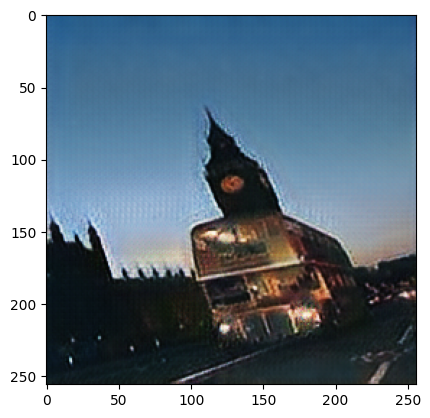

In [ ]:
import matplotlib.pyplot as plt

img = plt.imread('./results/winter2summer_yosemite_pretrained/test_latest/images/2015_01890_fake.png')
plt.imshow(img)

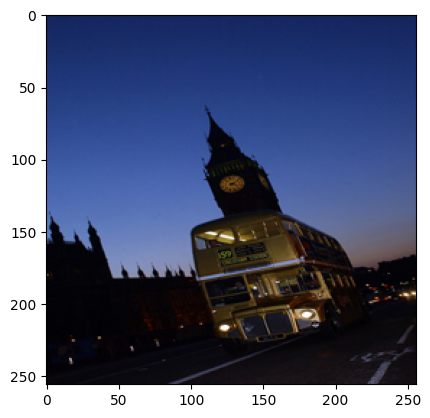

In [ ]:
import matplotlib.pyplot as plt

img = plt.imread('./results/winter2summer_yosemite_pretrained/test_latest/images/2015_01890_real.png')
plt.imshow(img)

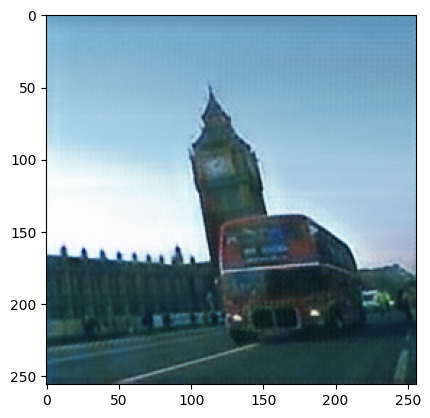

In [ ]:
import matplotlib.pyplot as plt

img = plt.imread('./results/winter2summer_yosemite_pretrained/test_latest/images/2015_01884_fake.png')
plt.imshow(img)

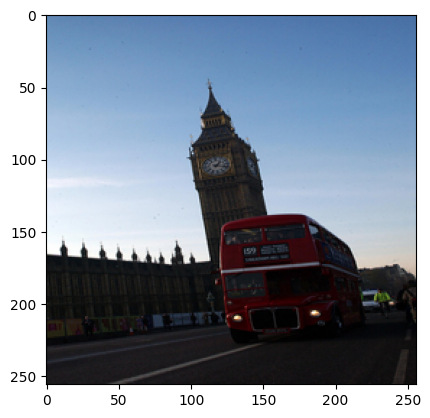

In [ ]:
import matplotlib.pyplot as plt

img = plt.imread('./results/winter2summer_yosemite_pretrained/test_latest/images/2015_01884_real.png')
plt.imshow(img)

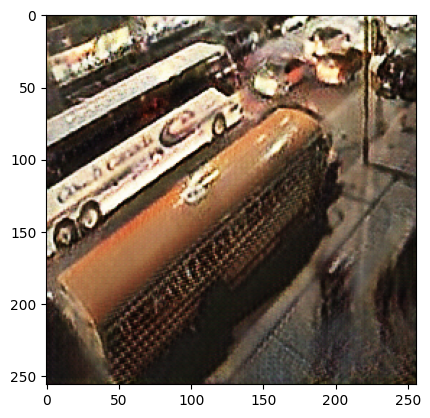

In [ ]:
import matplotlib.pyplot as plt

img = plt.imread('./results/winter2summer_yosemite_pretrained/test_latest/images/2015_01888_fake.png')
plt.imshow(img)

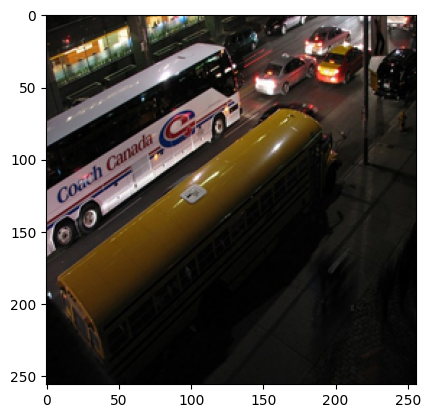

In [ ]:
import matplotlib.pyplot as plt

img = plt.imread('./results/winter2summer_yosemite_pretrained/test_latest/images/2015_01888_real.png')
plt.imshow(img)

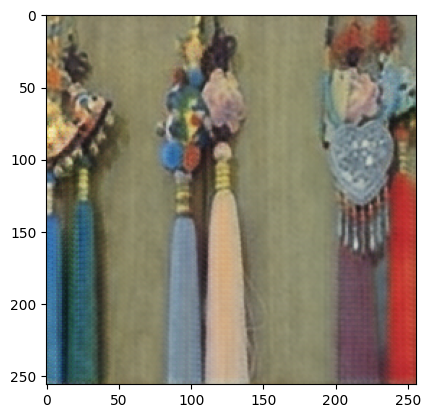

In [ ]:
import matplotlib.pyplot as plt

img = plt.imread('./results/winter2summer_yosemite_pretrained/test_latest/images/179_fake.png')
plt.imshow(img)

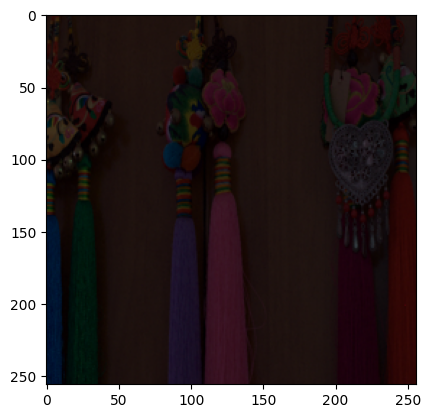

In [ ]:
import matplotlib.pyplot as plt

img = plt.imread('./results/winter2summer_yosemite_pretrained/test_latest/images/179_real.png')
plt.imshow(img)

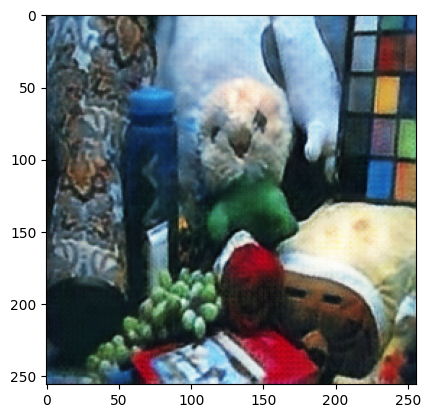

In [ ]:
import matplotlib.pyplot as plt

img = plt.imread('./results/winter2summer_yosemite_pretrained/test_latest/images/493_fake.png')
plt.imshow(img)

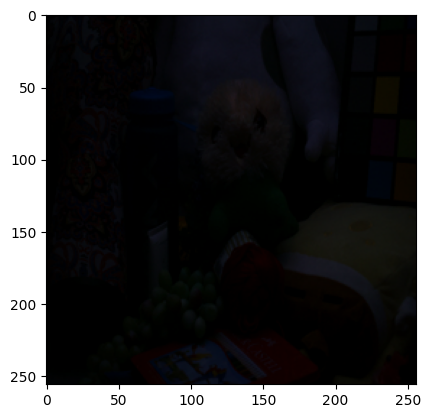

In [ ]:
import matplotlib.pyplot as plt

img = plt.imread('./results/winter2summer_yosemite_pretrained/test_latest/images/493_real.png')
plt.imshow(img)

In [1]:
!nvidia-smi

Tue May 26 09:01:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import psutil
import platform

print("CPU:", platform.processor())
print("RAM:", round(psutil.virtual_memory().total/1e9,2), "GB")
print("OS:", platform.platform())

CPU: x86_64
RAM: 13.61 GB
OS: Linux-6.6.122+-x86_64-with-glibc2.35


In [3]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: Tesla T4


In [8]:
import os

path="/content/drive/MyDrive/CycleGAN_Models/winter2summer_yosemite_pretrained"
print(os.listdir(path))

['105_net_G_A.pth', 'latest_net_G.pth', '105_net_G_B.pth', 'train_opt.txt', 'web', 'loss_log.txt', 'latest_net_G_A.pth', 'latest_net_G_B.pth', 'latest_net_D_A.pth', 'latest_net_D_B.pth', '5_net_G_A.pth', '5_net_G_B.pth', '5_net_D_A.pth', '5_net_D_B.pth', '10_net_G_A.pth', '10_net_G_B.pth', '10_net_D_A.pth', '10_net_D_B.pth', '15_net_G_A.pth', '15_net_G_B.pth', '15_net_D_A.pth', '15_net_D_B.pth', '20_net_G_A.pth', '20_net_G_B.pth', '20_net_D_A.pth', '20_net_D_B.pth', '25_net_G_A.pth', '25_net_G_B.pth', '25_net_D_A.pth', '25_net_D_B.pth', '30_net_G_A.pth', '30_net_G_B.pth', '30_net_D_A.pth', '30_net_D_B.pth', '35_net_G_A.pth', '35_net_G_B.pth', '35_net_D_A.pth', '35_net_D_B.pth', '40_net_G_A.pth', '40_net_G_B.pth', '40_net_D_A.pth', '40_net_D_B.pth', '45_net_G_A.pth', '45_net_G_B.pth', '45_net_D_A.pth', '45_net_D_B.pth', '50_net_G_A.pth', '50_net_G_B.pth', '50_net_D_A.pth', '50_net_D_B.pth', '55_net_G_A.pth', '55_net_G_B.pth', '55_net_D_A.pth', '55_net_D_B.pth', '60_net_G_A.pth', '60_net

In [10]:
with open("/content/drive/MyDrive/CycleGAN_Models/winter2summer_yosemite_pretrained/train_opt.txt") as f:
    print(f.read())

----------------- Options ---------------
               batch_size: 1                             
                    beta1: 0.5                           
          checkpoints_dir: ./checkpoints                 
           continue_train: False                         
                crop_size: 256                           
                 dataroot: ./dataset                     	[default: None]
             dataset_mode: unaligned                     
                direction: AtoB                          
             display_freq: 400                           
          display_winsize: 256                           
                    epoch: latest                        
              epoch_count: 1                             
                 gan_mode: lsgan                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
              

In [11]:
import torch

ckpt = torch.load(
"/content/drive/MyDrive/CycleGAN_Models/winter2summer_yosemite_pretrained/latest_net_G.pth",
map_location="cpu"
)

print(ckpt.keys())

odict_keys(['model.1.weight', 'model.1.bias', 'model.4.weight', 'model.4.bias', 'model.7.weight', 'model.7.bias', 'model.10.conv_block.1.weight', 'model.10.conv_block.1.bias', 'model.10.conv_block.5.weight', 'model.10.conv_block.5.bias', 'model.11.conv_block.1.weight', 'model.11.conv_block.1.bias', 'model.11.conv_block.5.weight', 'model.11.conv_block.5.bias', 'model.12.conv_block.1.weight', 'model.12.conv_block.1.bias', 'model.12.conv_block.5.weight', 'model.12.conv_block.5.bias', 'model.13.conv_block.1.weight', 'model.13.conv_block.1.bias', 'model.13.conv_block.5.weight', 'model.13.conv_block.5.bias', 'model.14.conv_block.1.weight', 'model.14.conv_block.1.bias', 'model.14.conv_block.5.weight', 'model.14.conv_block.5.bias', 'model.15.conv_block.1.weight', 'model.15.conv_block.1.bias', 'model.15.conv_block.5.weight', 'model.15.conv_block.5.bias', 'model.16.conv_block.1.weight', 'model.16.conv_block.1.bias', 'model.16.conv_block.5.weight', 'model.16.conv_block.5.bias', 'model.17.conv_blo

In [13]:
from models.networks import define_G

net = define_G(
3,3,64,'resnet_9blocks',
'instance',False,'normal',0.02
)

total = sum(p.numel() for p in net.parameters())
print(total)

11378179
